In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
brand_names = []
capacity = []
machine_type = []
load_type = []
rating = []
reviews_count = []
offer_per = []
price = []
speed1 = []

In [3]:
for page in range(1, 18):

    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    url = f"https://www.flipkart.com/search?q=washing+machine&page={page}"
    # url = f"https://www.flipkart.com/search?q=washing+machine&page={page}"
    res = requests.get(url, headers=headers)

    print("Page:", page, "Status:", res.status_code)

    soup = BeautifulSoup(res.text, "html.parser")

    titles = soup.find_all("div", class_="RG5Slk")
    ratings = soup.find_all("div", class_="MKiFS6")
    reviews = soup.find_all("span", class_="PvbNMB")
    prices = soup.find_all("div", class_="hZ3P6w DeU9vF")
    offers = soup.find_all("div", class_="HQe8jr")
    speeds = soup.find_all("ul", class_="HwRTzP")

    for title, rat, rev, pri, off, spe in zip(
        titles, ratings, reviews, prices, offers, speeds
    ):

        # Product title
        text = title.get_text(strip=True)

        # -----------------
        # 1. Brand
        # -----------------
        brand_names.append(text.split()[0])

        # -----------------
        # 2. Capacity
        # -----------------
        cap = re.search(r'(\d+(?:\.\d+)?)\s*kg',text,re.I)

        if cap:
            capacity.append(float(cap.group(1)))
        else:
            capacity.append(np.nan)

        # -----------------
        # 3. Machine Type
        # -----------------
        if re.search(r'Semi[- ]Automatic', text, re.I):
            machine_type.append("Semi Automatic")

        elif re.search(r'Fully[- ]Automatic', text, re.I):
            machine_type.append("Fully Automatic")

        else:
             machine_type.append(np.nan)

        # -----------------
        # 4. Load Type
        # -----------------
        if re.search(r'Top Load', text, re.I):
            load_type.append("Top Load")

        elif re.search(r'Front Load', text, re.I):
            load_type.append("Front Load")

        else:

            load_type.append(np.nan)

        # -----------------
        # 5. Rating
        # -----------------
        if rat:

            rating.append(
                rat.get_text(strip=True)
            )

        else:

            rating.append(np.nan)

        # -----------------
        # 6. Reviews
        # -----------------
        review_text = rev.get_text(" ", strip=True)

        match = re.search(r'([\d,]+)\s*Reviews',review_text,re.I)

        if match:
            reviews_count.append(int(match.group(1).replace(",", "")))

        else:
            reviews_count.append(np.nan)

        # -----------------
        # 7. Offer
        # -----------------
        if off:
            offer_per.append(off.get_text(strip=True))

        else:
            offer_per.append(np.nan)

        # -----------------
        # 8. Price
        # -----------------
        if pri:
            price.append(pri.get_text(strip=True))
            
        else:
            price.append(np.nan)

        # -----------------
        # 9. Speed
        # -----------------
        speed_text = spe.get_text(" ", strip=True)

        match_speed = re.search(r'(\d+)\s*',speed_text,re.I)

        if match_speed:
            speed1.append(match_speed.group(1))
            
        else:
            speed1.append(np.nan)

Page: 1 Status: 200
Page: 2 Status: 200
Page: 3 Status: 200
Page: 4 Status: 200
Page: 5 Status: 200
Page: 6 Status: 200
Page: 7 Status: 200
Page: 8 Status: 200
Page: 9 Status: 200
Page: 10 Status: 200
Page: 11 Status: 200
Page: 12 Status: 200
Page: 13 Status: 200
Page: 14 Status: 200
Page: 15 Status: 200
Page: 16 Status: 200
Page: 17 Status: 200


In [5]:
data = pd.DataFrame({
    "Brand": brand_names,
    "Capacity": capacity,
    "Machine Type": machine_type,
    "Load Type": load_type,
    "Rating": rating,
    "Reviews Count": reviews_count,
    "Offer": offer_per,
    "Price": price,
    "Speed": speed1
})
data.to_csv('Washing_machine.csv',index = False)

In [6]:
df = pd.read_csv("Washing_machine.csv")

In [7]:
# Display first 2 rows
df.head(2)

,Brand,Capacity,Machine Type,Load Type,Rating,Reviews Count,Offer,Price,Speed
0,Whirlpool,7.0,Semi Automatic,Top Load,4.4,855,14% off,"₹10,650",1400
1,LG,9.0,NaN,NaN,4.4,1551,20% off,"₹41,990",1200


In [8]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          364 non-null    object 
 1   Capacity       364 non-null    float64
 2   Machine Type   255 non-null    object 
 3   Load Type      250 non-null    object 
 4   Rating         364 non-null    float64
 5   Reviews Count  364 non-null    int64  
 6   Offer          364 non-null    object 
 7   Price          364 non-null    object 
 8   Speed          364 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 25.7+ KB


# Missing Values

In [9]:
df.isnull().sum()

Brand              0
Capacity           0
Machine Type     109
Load Type        114
Rating             0
Reviews Count      0
Offer              0
Price              0
Speed              0
dtype: int64

# Fill missing Machine Type values using the most common Machine Type for each Brand

In [10]:

df['Machine Type'] = df.groupby('Brand')['Machine Type'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Fill missing Load Type values using the most common Load Type for each Brand

In [11]:

df['Load Type'] = df.groupby('Brand')['Load Type'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Check Null Values After Filling

In [12]:
df.isnull().sum()

Brand             0
Capacity          0
Machine Type     13
Load Type        13
Rating            0
Reviews Count     0
Offer             0
Price             0
Speed             0
dtype: int64

# Fill Missing Loadtype and Machine type with unknown

In [13]:
df['Machine Type'] = df['Machine Type'].fillna('Unknown')
df['Load Type'] = df['Load Type'].fillna('Unknown')
# df['Capacity'] = df['Capacity'].fillna(df['Capacity'].mode()[0])
# Reset the index
df = df.reset_index(drop=True)

# Check Null Values After Filling

In [14]:
df.isnull().sum()

Brand            0
Capacity         0
Machine Type     0
Load Type        0
Rating           0
Reviews Count    0
Offer            0
Price            0
Speed            0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(60)

In [16]:
df[df.duplicated()].head()

,Brand,Capacity,Machine Type,Load Type,Rating,Reviews Count,Offer,Price,Speed
24,FOXSKY,9.0,Fully Automatic,Top Load,3.7,10,45% off,"₹12,490",740
25,Whirlpool,7.0,Semi Automatic,Top Load,4.4,855,14% off,"₹10,650",1400
46,FOXSKY,9.0,Fully Automatic,Top Load,3.7,10,45% off,"₹12,490",740
47,Whirlpool,7.0,Semi Automatic,Top Load,4.4,855,14% off,"₹10,650",1400
52,Kenstar,7.5,Fully Automatic,Top Load,4.2,2799,50% off,"₹11,990",700


In [17]:
df = df.drop_duplicates()
# Reset index after removing duplicates
df = df.reset_index(drop=True)

In [18]:
# Remove "% off" from Offer
df['Offer'] = (df['Offer'].str.replace('% off', '', regex=False))

# # Convert Offer to numeric
df['Offer'] = pd.to_numeric(df['Offer'], errors='coerce')

In [19]:
# Convert Rating from object/string to numeric

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [20]:
# Remove ₹ symbol and commas from Price
df['Price'] = (
    df['Price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)
# Convert Price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [21]:
df.head()

,Brand,Capacity,Machine Type,Load Type,Rating,Reviews Count,Offer,Price,Speed
0,Whirlpool,7.0,Semi Automatic,Top Load,4.4,855,14,10650,1400
1,LG,9.0,Semi Automatic,Top Load,4.4,1551,20,41990,1200
2,VW,8.5,Semi Automatic,Top Load,4.2,1014,49,5099,740
3,Samsung,7.0,Fully Automatic,Top Load,4.3,5833,15,18990,700
4,LG,7.0,Semi Automatic,Top Load,4.5,6130,29,11490,1350


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Univariant

# 1.Brand - Bar plot

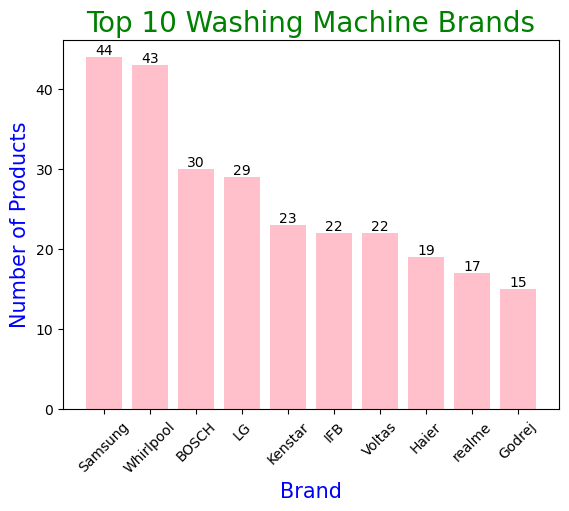

In [23]:

# Count the number of products for each brand
brand_count = df['Brand'].value_counts().head(10)

# Create a bar plot for the top 10 brands
a = plt.bar(brand_count.index, brand_count.values,color = 'pink')

plt.title('Top 10 Washing Machine Brands',fontsize = 20,color = 'green')
plt.xlabel('Brand',color = 'blue',fontsize = 15)
plt.ylabel('Number of Products',color = 'blue',fontsize = 15)

# Display the exact count on each bar
plt.bar_label(a)

plt.xticks(rotation=45)
plt.show()

# 2. Machine Type – Pie Chart

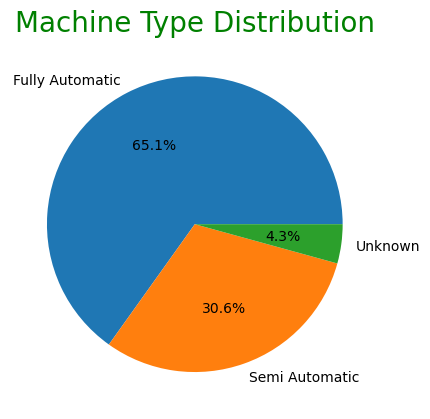

In [24]:
# Count the number of products for each machine type
machine_count = df['Machine Type'].value_counts()

# Create a pie chart to show the percentage distribution
plt.pie(machine_count.values,
        labels=machine_count.index,
        autopct='%1.1f%%')

plt.title('Machine Type Distribution',color = 'green',fontsize = 20)
plt.show()


# 3.Count plot

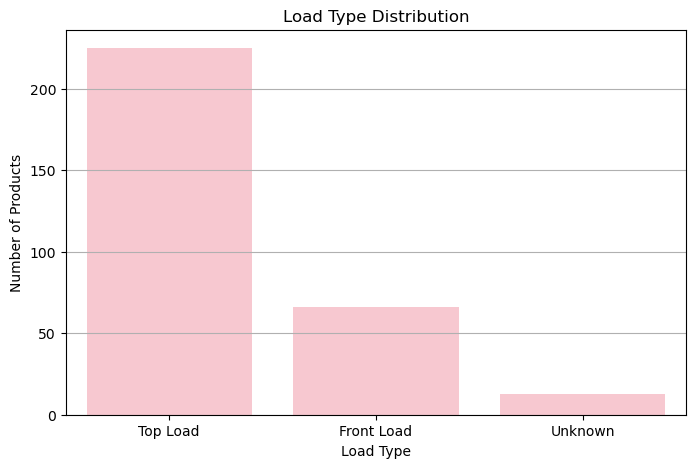

In [25]:
# Count the number of products for each Load Type

plt.figure(figsize=(8,5))

sns.countplot(x="Load Type", data=df,color = "pink")
plt.title("Load Type Distribution")
plt.xlabel("Load Type")
plt.ylabel("Number of Products")
plt.grid(axis = 'y')

plt.show()

# 4.Capacity - Histogram

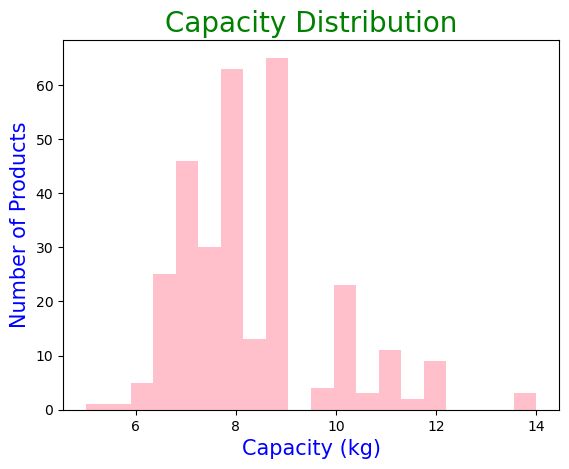

In [26]:

# Create histogram for washing machine capacity
plt.hist(df['Capacity'], bins=20,color = 'pink')

plt.title('Capacity Distribution',fontsize = 20,color = 'Green')
plt.xlabel('Capacity (kg)',color = 'blue',fontsize = 15)
plt.ylabel('Number of Products',color = 'blue',fontsize = 15)
plt.show()

# 5. Price – KDE Plot

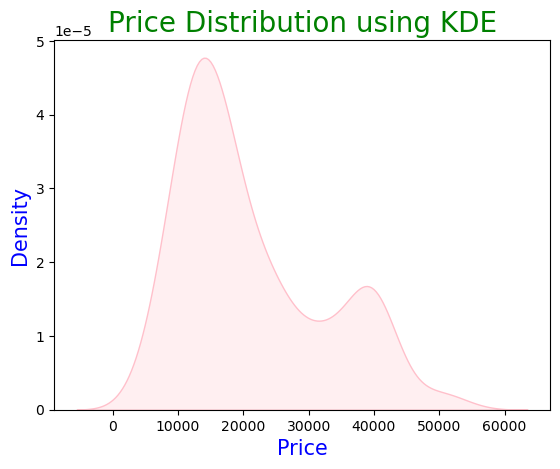

In [27]:
sns.kdeplot(df['Price'],fill = True,color = 'pink')

plt.title('Price Distribution using KDE',fontsize = 20,color = 'Green')
plt.xlabel('Price',color = 'blue',fontsize = 15)
plt.ylabel('Density',color = 'blue',fontsize = 15)
plt.show()

# 6. Speed – Histogram

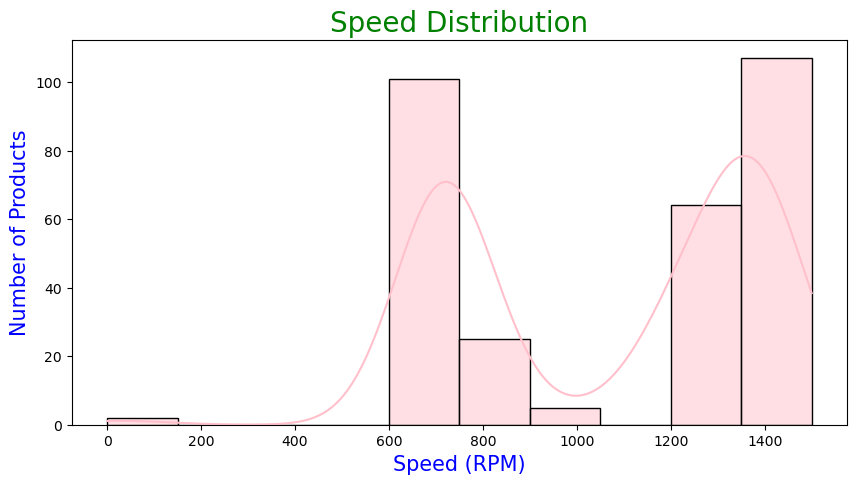

In [28]:
# Analyze the distribution of Speed

plt.figure(figsize=(10,5))

sns.histplot(df["Speed"], bins=10, kde=True,color = 'pink')

plt.title("Speed Distribution",fontsize = 20,color = 'green')
plt.xlabel("Speed (RPM)",fontsize = 15,color = 'blue')
plt.ylabel("Number of Products",fontsize = 15,color = 'blue')
plt.show()

# Bi variant

# 1. Load Type vs Price – Violin Plot

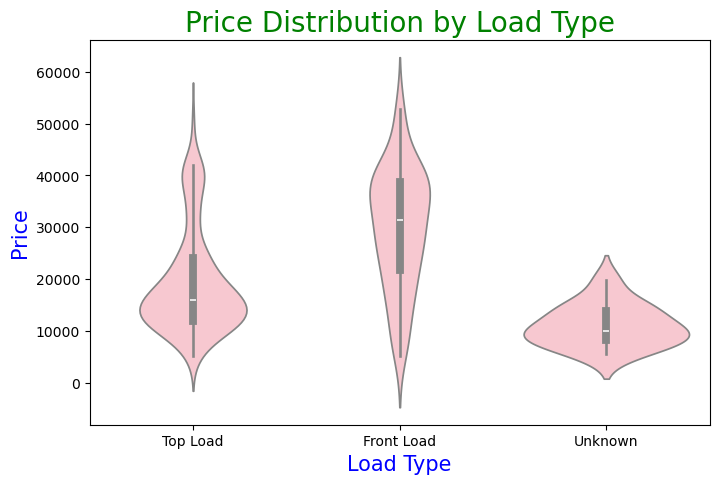

In [29]:
# Analyze Price distribution across different Load Types

plt.figure(figsize=(8,5))

sns.violinplot(x="Load Type", y="Price", data=df,color = 'pink')

plt.title("Price Distribution by Load Type",color = 'green',fontsize = 20)
plt.xlabel("Load Type",color = 'blue',fontsize = 15)
plt.ylabel("Price",color = 'blue',fontsize = 15)
plt.show()



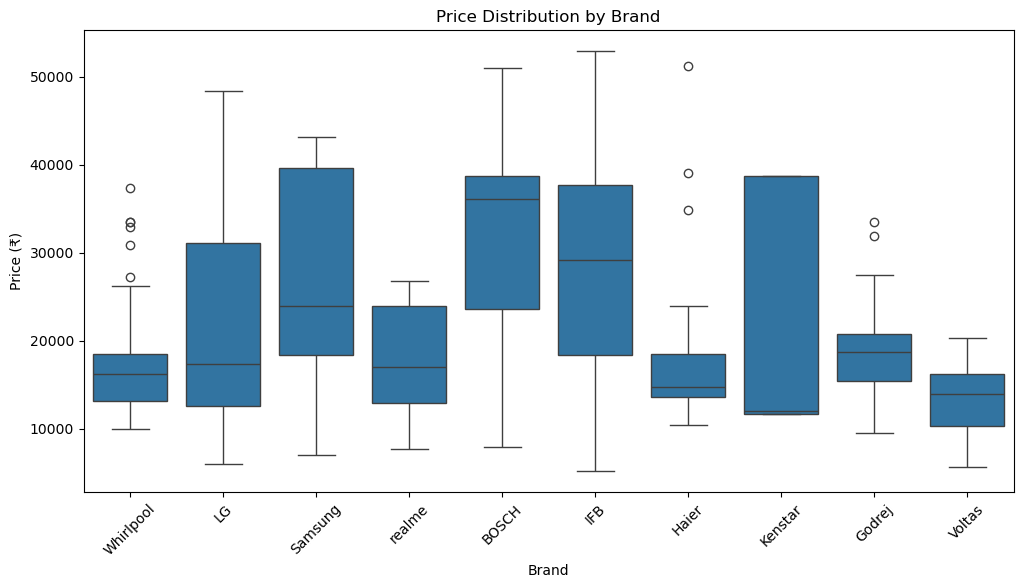

In [30]:
top_brands = df["Brand"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Brand",
    y="Price",
    data=df[df["Brand"].isin(top_brands)]
)

plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (₹)")
plt.xticks(rotation=45)

plt.show()

# Multi-varient 

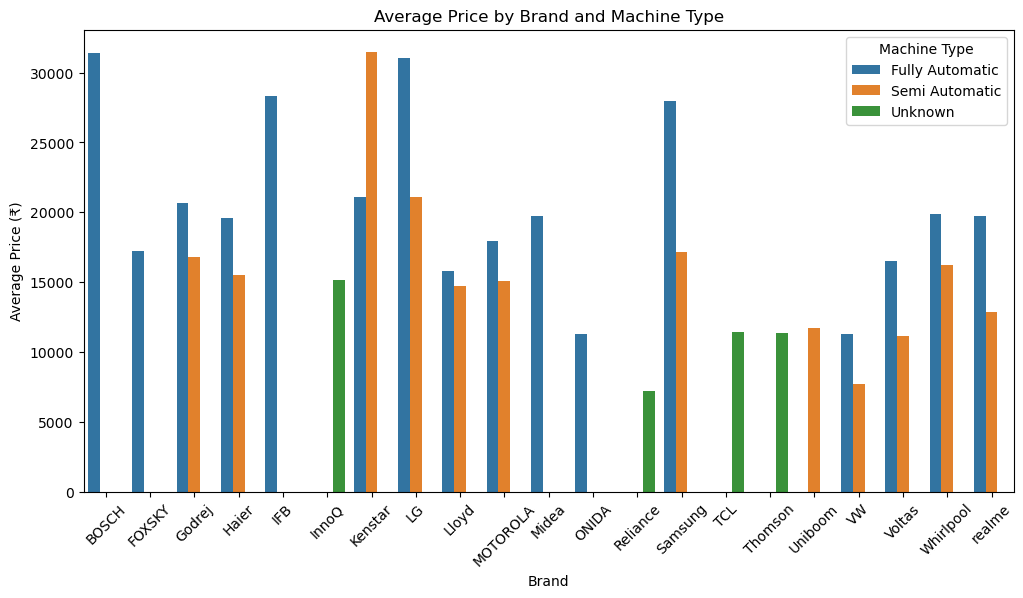

In [31]:
avg_price = df.groupby(
    ["Brand", "Machine Type"]
)["Price"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x="Brand",
    y="Price",
    hue="Machine Type",
    data=avg_price
)

plt.title("Average Price by Brand and Machine Type")
plt.xlabel("Brand")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

plt.show()

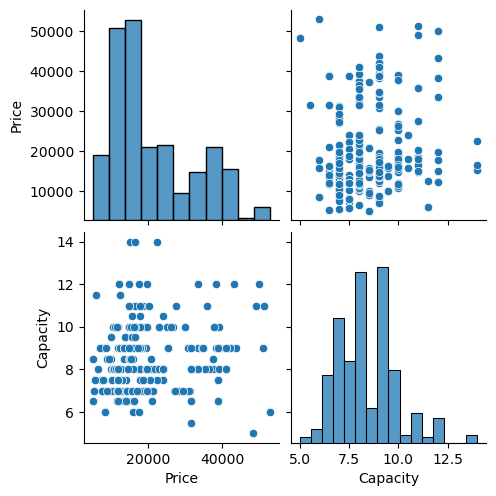

In [32]:
sns.pairplot(df[['Price', 'Capacity']])

plt.show()